Regularization is a technique used to prevent overfitting, where a model learns the noise in the training data rather than the underlying pattern, leading to poor performance on new data. It works by adding a "penalty" term to the Loss function.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1, l2, l1_l2

In [ ]:
data = pd.read_csv("/content/WineQT.csv")

In [ ]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

In [ ]:
X = data.drop('quality', axis=1)
y = data['quality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def build_model(regularizer=None):
    model = Sequential()
    model.add(Dense(32, activation='relu',
                    input_shape=(X_train.shape[1],),
                    kernel_regularizer=regularizer))
    model.add(Dense(16, activation='relu',
                    kernel_regularizer=regularizer))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
model_none = build_model()
history_none = model_none.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L1 Regularization (Lasso) adds the absolute value of the weights to the loss. It acts as a feature selector and forces weak features to have coefficients of exactly zero resulting in sparse model.

In [ ]:
model_l1 = build_model(l1(0.001))
history_l1 = model_l1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

L2 Regularization (Ridge) adds the squared magnitude of the weights to the loss. It forces weights to be very small, but rarely zero and distributes the error among all features resulting in a robust model where no single feature dominates.

In [ ]:
model_l2 = build_model(l2(0.001))
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

Elastic Net Regularization is a linear combination of L1 and L2. It is useful when there are correlated features. L1 might pick one at random, while Elastic Net will group them.

In [ ]:
model_en = build_model(l1_l2(l1=0.001, l2=0.001))
history_en = model_en.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

In [ ]:
models = {
    "No Regularization": model_none,
    "L1 Regularization": model_l1,
    "L2 Regularization": model_l2,
    "Elastic Net": model_en
}

for name, model in models.items():
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
No Regularization Accuracy: 0.7467
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
L1 Regularization Accuracy: 0.7467


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
L2 Regularization Accuracy: 0.7205


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Elastic Net Accuracy: 0.7380


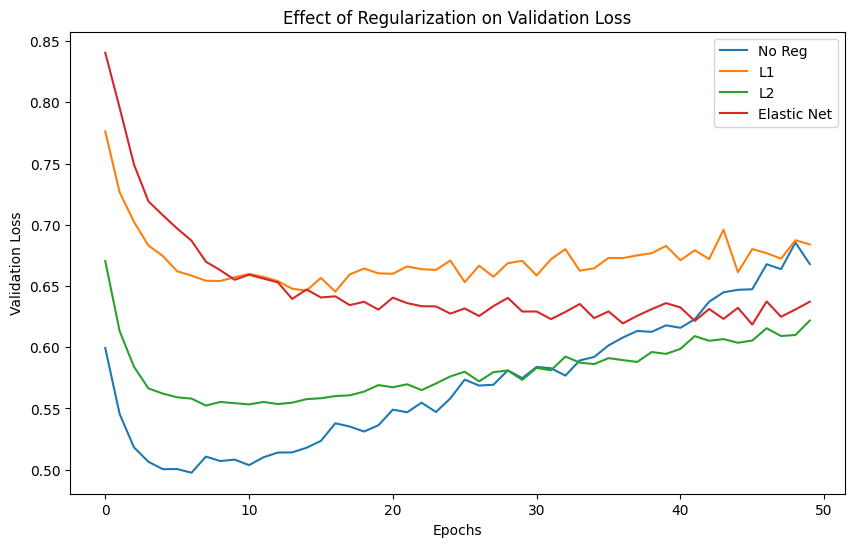

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_none.history['val_loss'], label='No Reg')
plt.plot(history_l1.history['val_loss'], label='L1')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_en.history['val_loss'], label='Elastic Net')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Effect of Regularization on Validation Loss")
plt.legend()
plt.show()